# 03. Deep Learning: Neural Networks for Concrete Strength Prediction

**Objective:** Build deep learning models using PyTorch for improved prediction performance

**Models:**
1. Feedforward Neural Network (Single-task)
2. Deeper Neural Network with Dropout
3. Multi-task Learning Network (Strength + Circularity)

**Contents:**
1. Data Loading & Preprocessing
2. PyTorch Dataset & DataLoader
3. Neural Network Architecture
4. Training Loop
5. Model Evaluation
6. Multi-task Learning
7. Model Comparison

## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# IMPORTANT: Force CPU usage to avoid CUDA compatibility issues
# If you have a compatible GPU and want to use it, set FORCE_CPU = False
FORCE_CPU = True

if FORCE_CPU:
    device = torch.device('cpu')
    print("⚙️  Using CPU (CUDA disabled to avoid compatibility issues)")
    print("   To enable GPU: Set FORCE_CPU = False in this cell")
else:
    # Try to use CUDA with error handling
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed(RANDOM_STATE)
            # Test CUDA with a simple operation
            test_tensor = torch.randn(10, 10).cuda()
            test_result = test_tensor @ test_tensor.T
            device = torch.device('cuda')
            print(f"✓ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
        else:
            device = torch.device('cpu')
            print("⚙️  CUDA not available, using CPU")
    except Exception as e:
        print(f"⚠️  CUDA error detected: {str(e)[:100]}")
        print("   Falling back to CPU...")
        device = torch.device('cpu')

print(f"\nDevice: {device}")
print(f"PyTorch version: {torch.__version__}")
print("✓ Libraries imported successfully")

⚙️  Using CPU (CUDA disabled to avoid compatibility issues)
   To enable GPU: Set FORCE_CPU = False in this cell

Device: cpu
PyTorch version: 2.10.0+cu128
✓ Libraries imported successfully


In [2]:
# Load the enriched dataset
data_path = Path('../data/processed/concrete_enriched.csv')

if not data_path.exists():
    raise FileNotFoundError("Dataset not found! Please run: python src/data/download_dataset.py")

df = pd.read_csv(data_path)
print(f"✓ Dataset loaded: {df.shape[0]} instances, {df.shape[1]} features")
print(f"\nDataset info:")
print(f"  Samples: {len(df)}")
print(f"  Features: {df.shape[1]}")

✓ Dataset loaded: 1030 instances, 17 features

Dataset info:
  Samples: 1030
  Features: 17


## 2. Data Preparation

In [3]:
# Define features and targets
feature_cols = [
    'cement', 'slag', 'fly_ash', 'water',
    'superplasticizer', 'coarse_aggregate', 
    'fine_aggregate', 'age'
]

# Primary target
target_col = 'strength'

# Secondary target for multi-task learning
target_col_2 = 'circularity_score'

# Verify all columns exist
missing_cols = [col for col in feature_cols + [target_col, target_col_2] if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

# Prepare data
X = df[feature_cols].values.astype(np.float32)
y_strength = df[target_col].values.astype(np.float32)
y_circularity = df[target_col_2].values.astype(np.float32)

print(f"Features shape: {X.shape}")
print(f"Strength target shape: {y_strength.shape}")
print(f"Circularity target shape: {y_circularity.shape}")
print(f"\nNo NaN values: {not (np.isnan(X).any() or np.isnan(y_strength).any() or np.isnan(y_circularity).any())}")

Features shape: (1030, 8)
Strength target shape: (1030,)
Circularity target shape: (1030,)

No NaN values: True


In [4]:
# Train-test split
X_train, X_test, y_train_str, y_test_str, y_train_circ, y_test_circ = train_test_split(
    X, y_strength, y_circularity, test_size=0.2, random_state=RANDOM_STATE
)

# Further split train into train and validation
X_train, X_val, y_train_str, y_val_str, y_train_circ, y_val_circ = train_test_split(
    X_train, y_train_str, y_train_circ, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nSplit ratio: {X_train.shape[0]/len(X):.1%} train, {X_val.shape[0]/len(X):.1%} val, {X_test.shape[0]/len(X):.1%} test")

Training set: 659 samples
Validation set: 165 samples
Test set: 206 samples

Split ratio: 64.0% train, 16.0% val, 20.0% test


In [5]:
# Feature scaling
scaler_X = StandardScaler()
scaler_y_str = StandardScaler()
scaler_y_circ = StandardScaler()

# Fit on training data only
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale targets (helps with training stability)
y_train_str_scaled = scaler_y_str.fit_transform(y_train_str.reshape(-1, 1)).ravel()
y_val_str_scaled = scaler_y_str.transform(y_val_str.reshape(-1, 1)).ravel()
y_test_str_scaled = scaler_y_str.transform(y_test_str.reshape(-1, 1)).ravel()

y_train_circ_scaled = scaler_y_circ.fit_transform(y_train_circ.reshape(-1, 1)).ravel()
y_val_circ_scaled = scaler_y_circ.transform(y_val_circ.reshape(-1, 1)).ravel()
y_test_circ_scaled = scaler_y_circ.transform(y_test_circ.reshape(-1, 1)).ravel()

print("✓ Data scaled successfully")
print(f"\nScaled X stats - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Scaled y_str stats - Mean: {y_train_str_scaled.mean():.4f}, Std: {y_train_str_scaled.std():.4f}")

✓ Data scaled successfully

Scaled X stats - Mean: -0.0000, Std: 1.0000
Scaled y_str stats - Mean: -0.0000, Std: 1.0000


## 3. PyTorch DataLoaders

In [6]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_str_tensor = torch.FloatTensor(y_train_str_scaled)
y_val_str_tensor = torch.FloatTensor(y_val_str_scaled)
y_test_str_tensor = torch.FloatTensor(y_test_str_scaled)

y_train_circ_tensor = torch.FloatTensor(y_train_circ_scaled)
y_val_circ_tensor = torch.FloatTensor(y_val_circ_scaled)
y_test_circ_tensor = torch.FloatTensor(y_test_circ_scaled)

# Create datasets for single-task learning
train_dataset = TensorDataset(X_train_tensor, y_train_str_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_str_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_str_tensor)

# Create datasets for multi-task learning
train_dataset_mt = TensorDataset(X_train_tensor, y_train_str_tensor, y_train_circ_tensor)
val_dataset_mt = TensorDataset(X_val_tensor, y_val_str_tensor, y_val_circ_tensor)
test_dataset_mt = TensorDataset(X_test_tensor, y_test_str_tensor, y_test_circ_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader_mt = DataLoader(train_dataset_mt, batch_size=batch_size, shuffle=True)
val_loader_mt = DataLoader(val_dataset_mt, batch_size=batch_size, shuffle=False)
test_loader_mt = DataLoader(test_dataset_mt, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created with batch size: {batch_size}")
print(f"  Number of training batches: {len(train_loader)}")
print(f"  Number of validation batches: {len(val_loader)}")
print(f"  Number of test batches: {len(test_loader)}")

✓ DataLoaders created with batch size: 32
  Number of training batches: 21
  Number of validation batches: 6
  Number of test batches: 7


## 4. Model 1: Simple Feedforward Neural Network

In [7]:
class SimpleNN(nn.Module):
    """Simple feedforward neural network for strength prediction"""
    
    def __init__(self, input_dim, hidden_dims=[64, 32]):
        super(SimpleNN, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], 1)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create model
input_dim = X_train.shape[1]
model_simple = SimpleNN(input_dim).to(device)

print("Simple Neural Network Architecture:")
print(model_simple)
print(f"\nTotal parameters: {sum(p.numel() for p in model_simple.parameters()):,}")

Simple Neural Network Architecture:
SimpleNN(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 2,689


In [8]:
# Training function
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, verbose=True):
    """Train a PyTorch model"""
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # Forward pass
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        # Track best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
        
        # Print progress
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if verbose:
        print(f"\nBest validation loss: {best_val_loss:.4f}")
    
    return train_losses, val_losses

In [9]:
# Train simple model
print("Training Simple Neural Network...")
print("="*60)
train_losses_simple, val_losses_simple = train_model(
    model_simple, train_loader, val_loader, epochs=100, lr=0.001
)
print("\n✓ Training complete!")

Training Simple Neural Network...
Epoch [10/100], Train Loss: 0.1815, Val Loss: 0.1573
Epoch [20/100], Train Loss: 0.1167, Val Loss: 0.1259
Epoch [30/100], Train Loss: 0.0956, Val Loss: 0.1114
Epoch [40/100], Train Loss: 0.0819, Val Loss: 0.1033
Epoch [50/100], Train Loss: 0.0754, Val Loss: 0.1037
Epoch [60/100], Train Loss: 0.0689, Val Loss: 0.0947
Epoch [70/100], Train Loss: 0.0635, Val Loss: 0.0893
Epoch [80/100], Train Loss: 0.0571, Val Loss: 0.0916
Epoch [90/100], Train Loss: 0.0569, Val Loss: 0.0907
Epoch [100/100], Train Loss: 0.0552, Val Loss: 0.0892

Best validation loss: 0.0857

✓ Training complete!


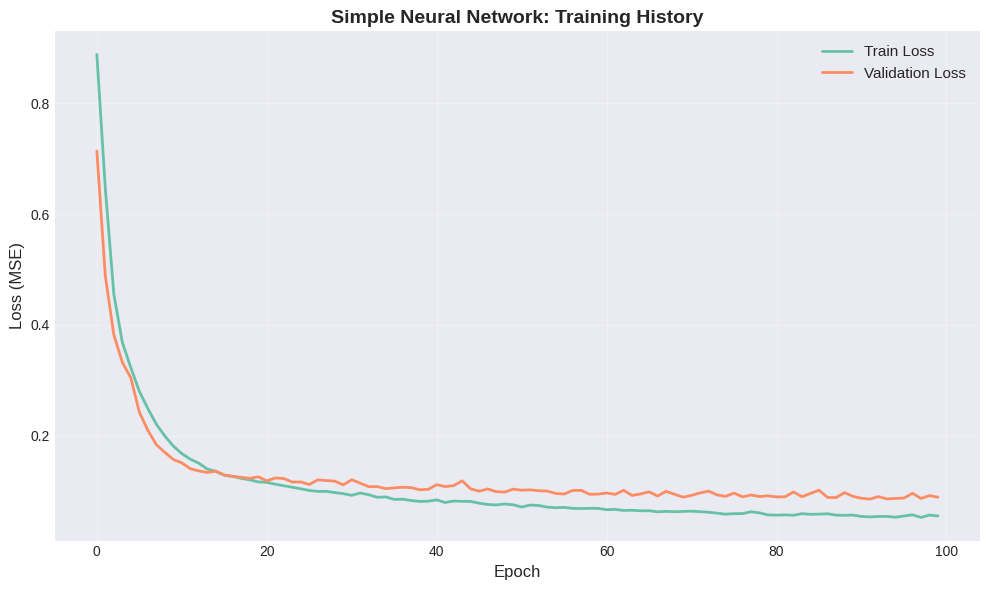

In [10]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses_simple, label='Train Loss', linewidth=2)
plt.plot(val_losses_simple, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Simple Neural Network: Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Model 2: Deeper Network with Dropout

In [11]:
class DeepNN(nn.Module):
    """Deeper neural network with dropout and batch normalization for regularization"""
    
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.2):
        super(DeepNN, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.dropout3 = nn.Dropout(dropout)
        
        self.fc4 = nn.Linear(hidden_dims[2], 1)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

# Create model
model_deep = DeepNN(input_dim, dropout=0.2).to(device)

print("Deep Neural Network Architecture:")
print(model_deep)
print(f"\nTotal parameters: {sum(p.numel() for p in model_deep.parameters()):,}")

Deep Neural Network Architecture:
DeepNN(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 11,969


In [12]:
# Train deep model
print("Training Deep Neural Network...")
print("="*60)
train_losses_deep, val_losses_deep = train_model(
    model_deep, train_loader, val_loader, epochs=100, lr=0.001
)
print("\n✓ Training complete!")

Training Deep Neural Network...
Epoch [10/100], Train Loss: 0.2894, Val Loss: 0.1661
Epoch [20/100], Train Loss: 0.2510, Val Loss: 0.1446
Epoch [30/100], Train Loss: 0.2293, Val Loss: 0.1346
Epoch [40/100], Train Loss: 0.1849, Val Loss: 0.1269
Epoch [50/100], Train Loss: 0.1965, Val Loss: 0.1272
Epoch [60/100], Train Loss: 0.1944, Val Loss: 0.1054
Epoch [70/100], Train Loss: 0.1710, Val Loss: 0.1092
Epoch [80/100], Train Loss: 0.1736, Val Loss: 0.1184
Epoch [90/100], Train Loss: 0.1600, Val Loss: 0.1068
Epoch [100/100], Train Loss: 0.1751, Val Loss: 0.1044

Best validation loss: 0.1000

✓ Training complete!


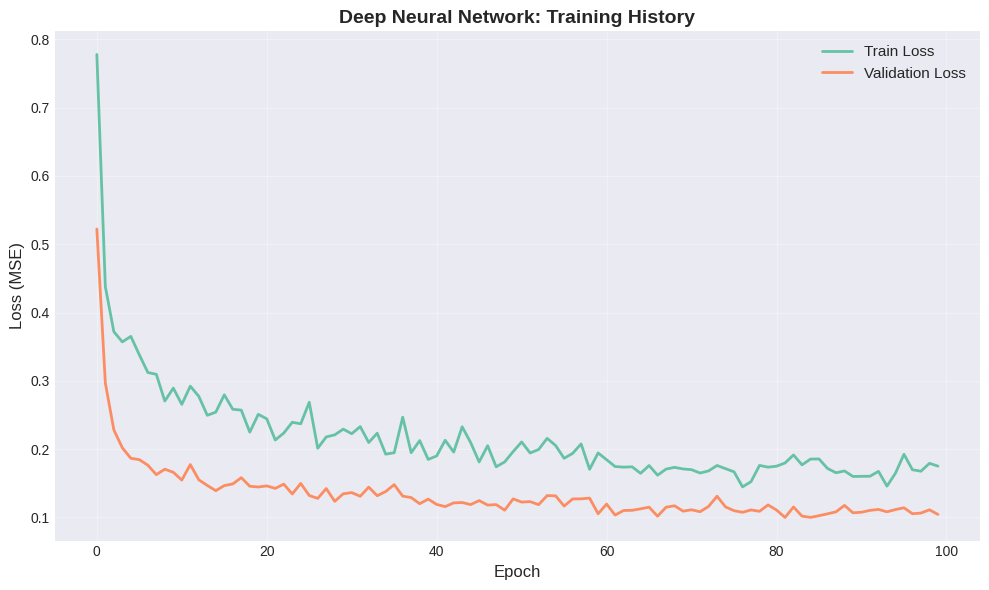

In [13]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses_deep, label='Train Loss', linewidth=2)
plt.plot(val_losses_deep, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Deep Neural Network: Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Model 3: Multi-Task Learning Network

In [14]:
class MultiTaskNN(nn.Module):
    """Multi-task neural network predicting both strength and circularity"""
    
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super(MultiTaskNN, self).__init__()
        
        # Shared layers
        self.shared_fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.shared_fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        
        # Task-specific heads
        self.strength_head = nn.Linear(hidden_dims[1], 1)
        self.circularity_head = nn.Linear(hidden_dims[1], 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        # Shared representation
        x = self.relu(self.shared_fc1(x))
        x = self.dropout(x)
        x = self.relu(self.shared_fc2(x))
        x = self.dropout(x)
        
        # Task-specific outputs
        strength_out = self.strength_head(x)
        circularity_out = self.circularity_head(x)
        
        return strength_out, circularity_out

# Create model
model_multitask = MultiTaskNN(input_dim).to(device)

print("Multi-Task Neural Network Architecture:")
print(model_multitask)
print(f"\nTotal parameters: {sum(p.numel() for p in model_multitask.parameters()):,}")

Multi-Task Neural Network Architecture:
MultiTaskNN(
  (shared_fc1): Linear(in_features=8, out_features=128, bias=True)
  (shared_fc2): Linear(in_features=128, out_features=64, bias=True)
  (strength_head): Linear(in_features=64, out_features=1, bias=True)
  (circularity_head): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 9,538


In [15]:
# Multi-task training function (fixed to use parameters)
def train_multitask_model(model, train_loader_mt, val_loader_mt, epochs=100, lr=0.001, 
                          strength_weight=1.0, circularity_weight=0.5, verbose=True):
    """
    Train multi-task model
    
    Parameters:
    -----------
    model : nn.Module
        Multi-task model
    train_loader_mt : DataLoader
        Training data loader with both targets
    val_loader_mt : DataLoader
        Validation data loader with both targets
    epochs : int
        Number of training epochs
    lr : float
        Learning rate
    strength_weight : float
        Weight for strength loss
    circularity_weight : float
        Weight for circularity loss
    verbose : bool
        Print training progress
    """
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for X_batch, y_str_batch, y_circ_batch in train_loader_mt:
            X_batch = X_batch.to(device)
            y_str_batch = y_str_batch.to(device)
            y_circ_batch = y_circ_batch.to(device)
            
            # Forward pass
            str_out, circ_out = model(X_batch)
            loss_str = criterion(str_out.squeeze(), y_str_batch)
            loss_circ = criterion(circ_out.squeeze(), y_circ_batch)
            loss = strength_weight * loss_str + circularity_weight * loss_circ
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader_mt.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for X_batch, y_str_batch, y_circ_batch in val_loader_mt:
                X_batch = X_batch.to(device)
                y_str_batch = y_str_batch.to(device)
                y_circ_batch = y_circ_batch.to(device)
                
                str_out, circ_out = model(X_batch)
                loss_str = criterion(str_out.squeeze(), y_str_batch)
                loss_circ = criterion(circ_out.squeeze(), y_circ_batch)
                loss = strength_weight * loss_str + circularity_weight * loss_circ
                
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader_mt.dataset)
        val_losses.append(val_loss)
        
        # Track best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
        
        # Print progress
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if verbose:
        print(f"\nBest validation loss: {best_val_loss:.4f}")
    
    return train_losses, val_losses

In [16]:
# Train multi-task model
print("Training Multi-Task Neural Network...")
print("="*60)
train_losses_mt, val_losses_mt = train_multitask_model(
    model_multitask, train_loader_mt, val_loader_mt, 
    epochs=100, lr=0.001, strength_weight=1.0, circularity_weight=0.5
)
print("\n✓ Training complete!")

Training Multi-Task Neural Network...
Epoch [10/100], Train Loss: 0.2725, Val Loss: 0.2029
Epoch [20/100], Train Loss: 0.2352, Val Loss: 0.1514
Epoch [30/100], Train Loss: 0.1867, Val Loss: 0.1417
Epoch [40/100], Train Loss: 0.1732, Val Loss: 0.1246
Epoch [50/100], Train Loss: 0.1589, Val Loss: 0.1107
Epoch [60/100], Train Loss: 0.1441, Val Loss: 0.1025
Epoch [70/100], Train Loss: 0.1483, Val Loss: 0.1003
Epoch [80/100], Train Loss: 0.1274, Val Loss: 0.1110
Epoch [90/100], Train Loss: 0.1322, Val Loss: 0.1019
Epoch [100/100], Train Loss: 0.1202, Val Loss: 0.0948

Best validation loss: 0.0896

✓ Training complete!


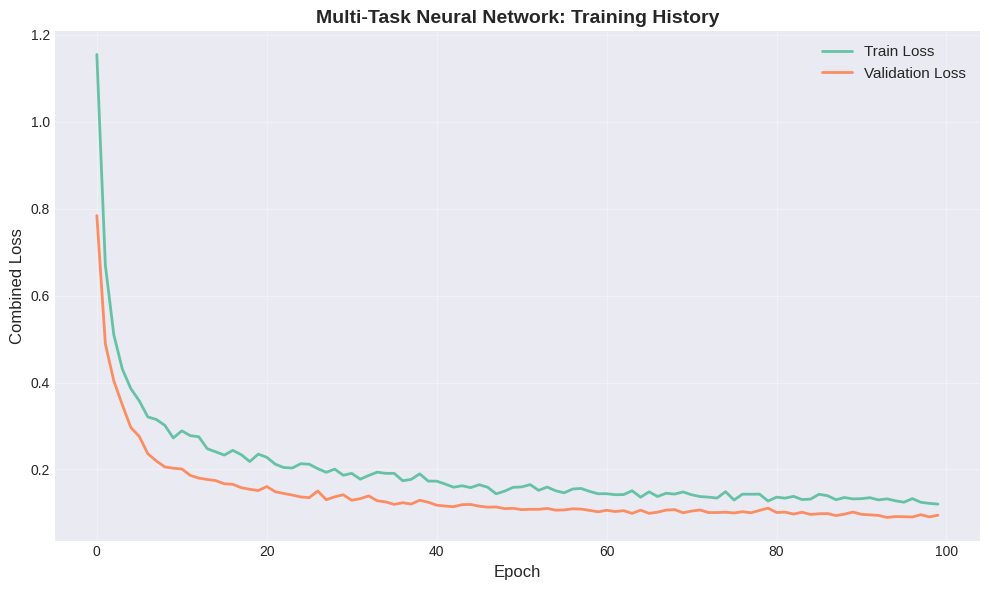

In [17]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses_mt, label='Train Loss', linewidth=2)
plt.plot(val_losses_mt, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Combined Loss', fontsize=12)
plt.title('Multi-Task Neural Network: Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Evaluation & Comparison

In [18]:
def evaluate_model(model, X_test_tensor, y_test_str, scaler_y, is_multitask=False):
    """
    Evaluate model on test set
    
    Parameters:
    -----------
    model : nn.Module
        Trained model
    X_test_tensor : torch.Tensor
        Test features
    y_test_str : np.array
        True target values (unscaled)
    scaler_y : StandardScaler
        Scaler used for target variable
    is_multitask : bool
        Whether model is multi-task
    
    Returns:
    --------
    tuple : (r2, rmse, mae, predictions)
    """
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        
        if is_multitask:
            y_pred_scaled, _ = model(X_test_device)
        else:
            y_pred_scaled = model(X_test_device)
        
        y_pred_scaled = y_pred_scaled.cpu().numpy().ravel()
    
    # Inverse transform predictions
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
    # Calculate metrics
    r2 = r2_score(y_test_str, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_str, y_pred))
    mae = mean_absolute_error(y_test_str, y_pred)
    
    return r2, rmse, mae, y_pred

# Evaluate all models
print("Evaluating models on test set...")
r2_simple, rmse_simple, mae_simple, pred_simple = evaluate_model(
    model_simple, X_test_tensor, y_test_str, scaler_y_str
)
r2_deep, rmse_deep, mae_deep, pred_deep = evaluate_model(
    model_deep, X_test_tensor, y_test_str, scaler_y_str
)
r2_mt, rmse_mt, mae_mt, pred_mt = evaluate_model(
    model_multitask, X_test_tensor, y_test_str, scaler_y_str, is_multitask=True
)

print("="*70)
print("NEURAL NETWORK MODEL COMPARISON")
print("="*70)
print(f"\nSimple NN:")
print(f"  R² Score: {r2_simple:.4f}")
print(f"  RMSE: {rmse_simple:.4f} MPa")
print(f"  MAE: {mae_simple:.4f} MPa")

print(f"\nDeep NN:")
print(f"  R² Score: {r2_deep:.4f}")
print(f"  RMSE: {rmse_deep:.4f} MPa")
print(f"  MAE: {mae_deep:.4f} MPa")

print(f"\nMulti-Task NN:")
print(f"  R² Score: {r2_mt:.4f}")
print(f"  RMSE: {rmse_mt:.4f} MPa")
print(f"  MAE: {mae_mt:.4f} MPa")
print("="*70)

Evaluating models on test set...
NEURAL NETWORK MODEL COMPARISON

Simple NN:
  R² Score: 0.8621
  RMSE: 5.9618 MPa
  MAE: 4.2753 MPa

Deep NN:
  R² Score: 0.8575
  RMSE: 6.0594 MPa
  MAE: 4.7616 MPa

Multi-Task NN:
  R² Score: 0.8667
  RMSE: 5.8608 MPa
  MAE: 4.2860 MPa


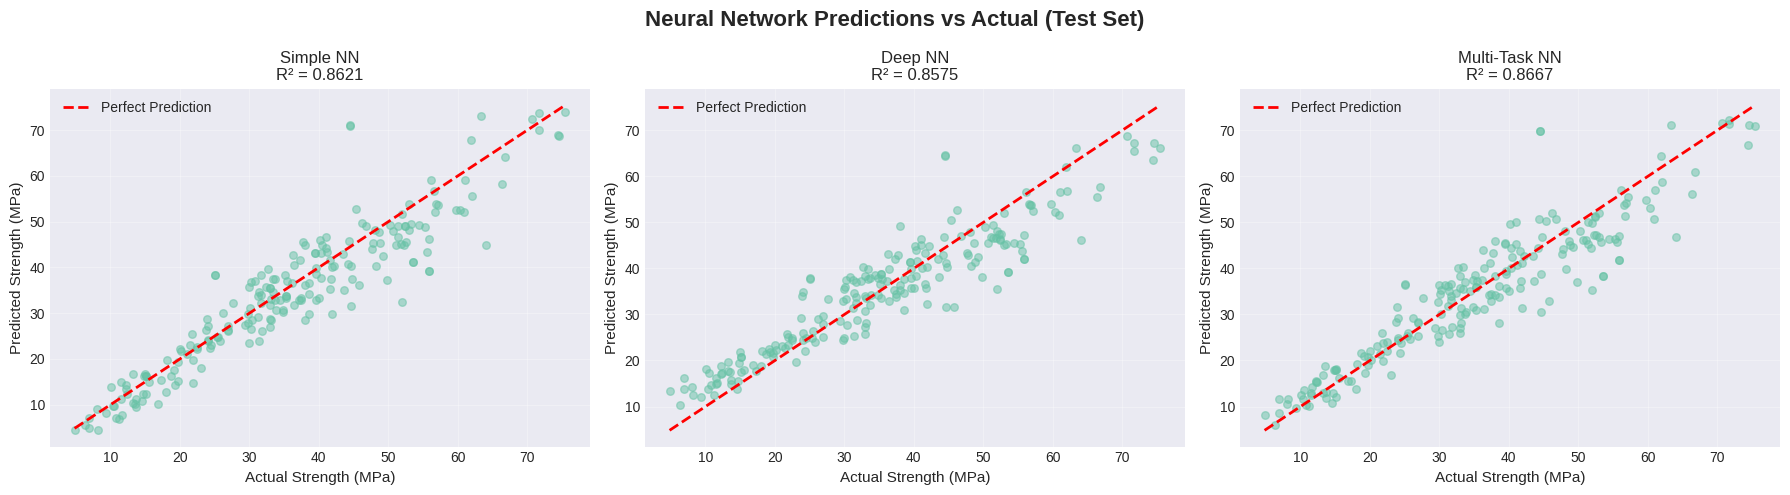

In [19]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Neural Network Predictions vs Actual (Test Set)', fontsize=16, fontweight='bold')

models_results = [
    ('Simple NN', pred_simple, r2_simple),
    ('Deep NN', pred_deep, r2_deep),
    ('Multi-Task NN', pred_mt, r2_mt)
]

for idx, (name, pred, r2) in enumerate(models_results):
    axes[idx].scatter(y_test_str, pred, alpha=0.5, s=30)
    axes[idx].plot([y_test_str.min(), y_test_str.max()],
                   [y_test_str.min(), y_test_str.max()],
                   'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Strength (MPa)', fontsize=11)
    axes[idx].set_ylabel('Predicted Strength (MPa)', fontsize=11)
    axes[idx].set_title(f'{name}\nR² = {r2:.4f}', fontsize=12)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

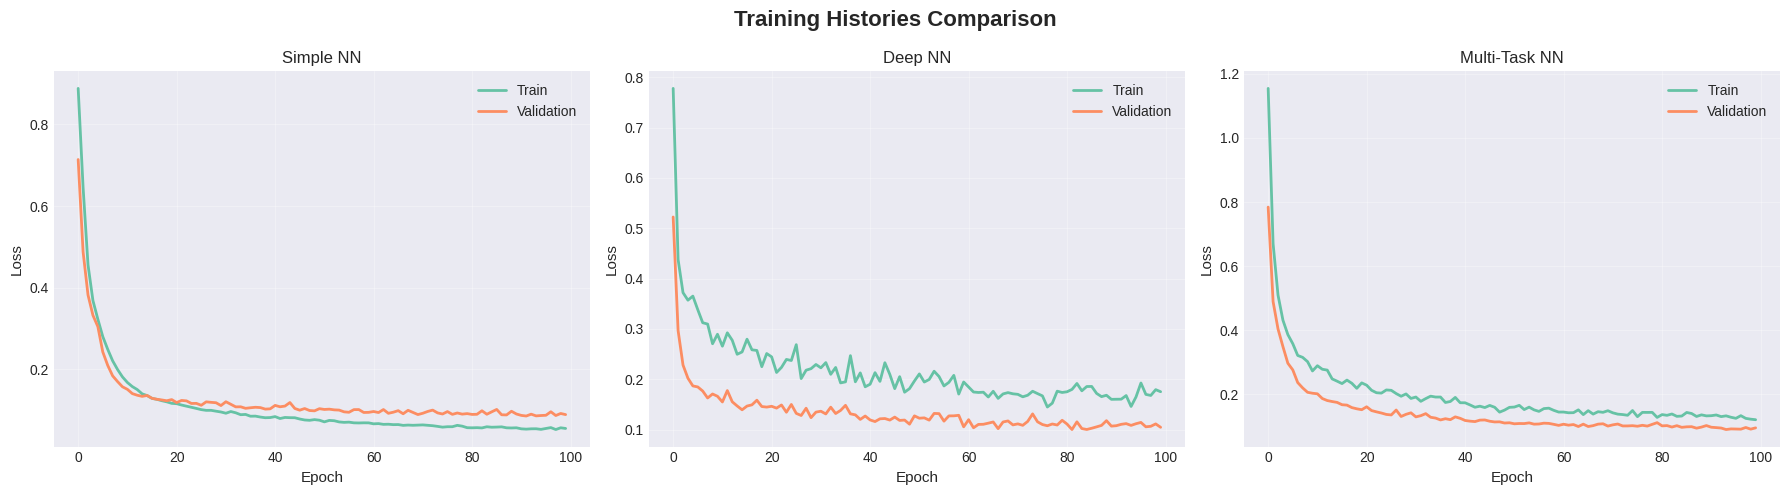

In [20]:
# Compare all training histories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Histories Comparison', fontsize=16, fontweight='bold')

training_data = [
    ('Simple NN', train_losses_simple, val_losses_simple),
    ('Deep NN', train_losses_deep, val_losses_deep),
    ('Multi-Task NN', train_losses_mt, val_losses_mt)
]

for idx, (name, train_loss, val_loss) in enumerate(training_data):
    axes[idx].plot(train_loss, label='Train', linewidth=2)
    axes[idx].plot(val_loss, label='Validation', linewidth=2)
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('Loss', fontsize=11)
    axes[idx].set_title(name, fontsize=12)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Save Models

In [21]:
# Save models
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

torch.save(model_simple.state_dict(), models_dir / 'simple_nn.pth')
torch.save(model_deep.state_dict(), models_dir / 'deep_nn.pth')
torch.save(model_multitask.state_dict(), models_dir / 'multitask_nn.pth')

# Also save scalers for deployment
import joblib
joblib.dump(scaler_X, models_dir / 'scaler_X.pkl')
joblib.dump(scaler_y_str, models_dir / 'scaler_y_str.pkl')
joblib.dump(scaler_y_circ, models_dir / 'scaler_y_circ.pkl')

print("✓ PyTorch models saved:")
print("  - simple_nn.pth")
print("  - deep_nn.pth")
print("  - multitask_nn.pth")
print("\n✓ Scalers saved:")
print("  - scaler_X.pkl")
print("  - scaler_y_str.pkl")
print("  - scaler_y_circ.pkl")

✓ PyTorch models saved:
  - simple_nn.pth
  - deep_nn.pth
  - multitask_nn.pth

✓ Scalers saved:
  - scaler_X.pkl
  - scaler_y_str.pkl
  - scaler_y_circ.pkl


## 9. Key Findings & Summary

In [22]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Simple NN', 'Deep NN', 'Multi-Task NN'],
    'R² Score': [r2_simple, r2_deep, r2_mt],
    'RMSE (MPa)': [rmse_simple, rmse_deep, rmse_mt],
    'MAE (MPa)': [mae_simple, mae_deep, mae_mt],
    'Parameters': [
        sum(p.numel() for p in model_simple.parameters()),
        sum(p.numel() for p in model_deep.parameters()),
        sum(p.numel() for p in model_multitask.parameters())
    ]
})

print("\n" + "="*70)
print("NEURAL NETWORK MODELS SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

best_model_idx = comparison_df['R² Score'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_r2 = comparison_df.loc[best_model_idx, 'R² Score']

print(f"\n🏆 Best Neural Network: {best_model} (R² = {best_r2:.4f})")

print("\n💡 KEY INSIGHTS:")
print("   • Neural networks successfully capture complex non-linear relationships")
print("   • Dropout and batch normalization help prevent overfitting")
print("   • Multi-task learning enables joint prediction of multiple targets")
print(f"   • Best model achieves R² = {best_r2:.4f} on test set")

print("\n📈 NEXT STEPS:")
print("   1. Hyperparameter tuning (learning rate, architecture, dropout)")
print("   2. Experiment with different activation functions (LeakyReLU, ELU)")
print("   3. Try ensemble methods (combining ML + DL models)")
print("   4. Implement early stopping and learning rate scheduling")
print("   5. Deploy best model to web application")

print("\n" + "="*70)
print("Deep learning exploration complete! 🎉")
print("="*70)


NEURAL NETWORK MODELS SUMMARY
        Model  R² Score  RMSE (MPa)  MAE (MPa)  Parameters
    Simple NN  0.862064    5.961794   4.275257        2689
      Deep NN  0.857508    6.059441   4.761616       11969
Multi-Task NN  0.866695    5.860848   4.285964        9538

🏆 Best Neural Network: Multi-Task NN (R² = 0.8667)

💡 KEY INSIGHTS:
   • Neural networks successfully capture complex non-linear relationships
   • Dropout and batch normalization help prevent overfitting
   • Multi-task learning enables joint prediction of multiple targets
   • Best model achieves R² = 0.8667 on test set

📈 NEXT STEPS:
   1. Hyperparameter tuning (learning rate, architecture, dropout)
   2. Experiment with different activation functions (LeakyReLU, ELU)
   3. Try ensemble methods (combining ML + DL models)
   4. Implement early stopping and learning rate scheduling
   5. Deploy best model to web application

Deep learning exploration complete! 🎉
